# Implémentation de la méthode CDF-t

## Importation des bibliothèques

In [1]:
%pip install -q -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [1]:
from functions import ( 
    csv_to_pd_univ, 
    cdf_t_univ, 
    plot_distributions,
    comparer_distributions,
    extract_month_data,
    cdf_t_multiv,
    gaussian_ot,
    compare_joint_distributions,
    compare_spearman,
    compare_distributions,
    compare_spearman_frobenius
)

from dOTC import dOTC_df

import numpy as np
import pandas as pd
from scipy import stats

In [2]:
#choix du mois
month = 12

## Implémentation CDF-t univariée (température)

### Comparaison passé/futur dans le modèle et dans les observations (observations futures = valeurs corrigées)

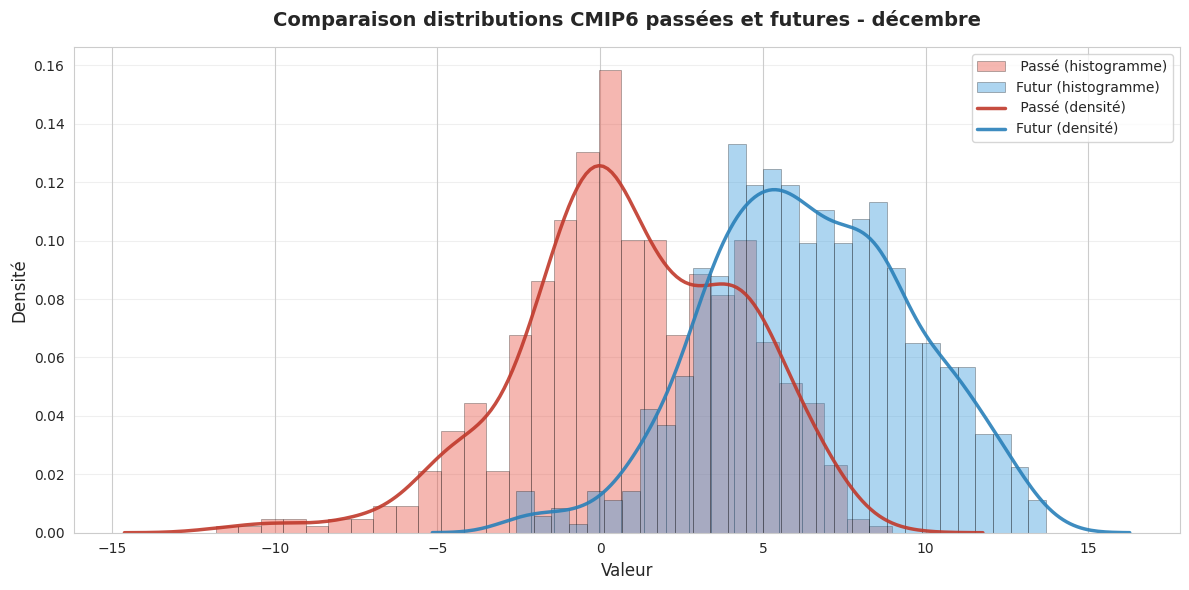

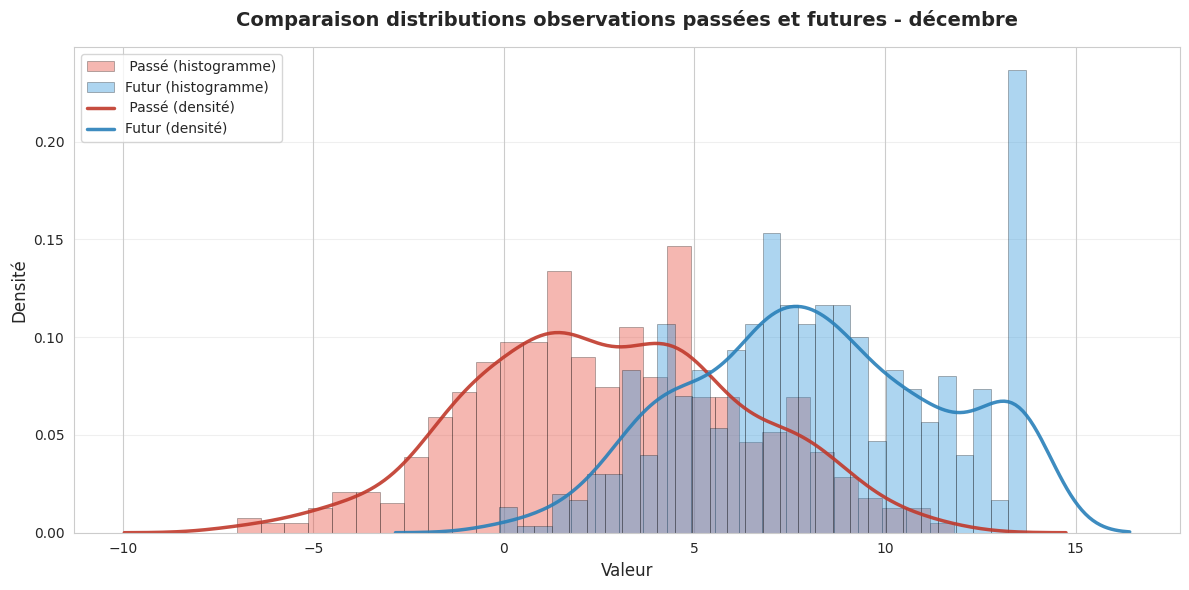

In [3]:
CMIP6_hist = csv_to_pd_univ(r"data/CMIP6_historical.csv", month, "tas", years = (1995,2014))
CMIP6_futur = csv_to_pd_univ(r"data/CMIP6_ssp585.csv", month, "tas", years= (2080,2100))
obs_hist = csv_to_pd_univ(r"data/obs.csv", month, "tas", years= (1995,2014))
_ ,modele_futur_corrige  = cdf_t_univ(CMIP6_hist,obs_hist,CMIP6_futur) 

#Représentations graphiques
plot_distributions((CMIP6_hist, CMIP6_futur),"Comparaison distributions CMIP6 passées et futures - décembre",("Passé","Futur"))
plot_distributions((obs_hist,modele_futur_corrige),"Comparaison distributions observations passées et futures - décembre",("Passé","Futur") )

### Comparaison modèle/observations dans le passé et dans le futur (avec valeurs corrigées)

In [ ]:
#Comparaison passé
plot_distributions((CMIP6_hist, obs_hist),
                           "Comparaison modèle et observations - passé - décembre",
                           ("valeurs modèles","observations"))

In [ ]:
#Comparaison futur 
plot_distributions((CMIP6_futur, modele_futur_corrige),
                           "Comparaison modèle et observations (corrections) - futur - décembre",
                           ("valeurs modèles","observations (corrections)"))

### Cas gaussien

In [ ]:
#Sélection mois et variable
CMIP6_hist = csv_to_pd_univ("data/CMIP6_historical.csv", month, "tas", years = (1995,2014))
CMIP6_futur = csv_to_pd_univ("data/CMIP6_ssp585.csv", month, "tas", years= (2080,2100))
obs_hist = csv_to_pd_univ("data/obs.csv", month, "tas" , years = (1995,2014))


# ============================================================================
# ÉTAPE 1 : Estimer les paramètres des lois gaussiennes
# ============================================================================

# Extraire les données (supposant une seule colonne par DataFrame)
data_CMIP6_hist = CMIP6_hist.iloc[:, 0]
data_CMIP6_futur = CMIP6_futur.iloc[:, 0]
data_obs_hist = obs_hist.iloc[:, 0]

# Estimer les paramètres avec Maximum de Vraisemblance (MLE)
mu_CMIP6_hist, sigma_CMIP6_hist = stats.norm.fit(data_CMIP6_hist)
mu_CMIP6_futur, sigma_CMIP6_futur = stats.norm.fit(data_CMIP6_futur)
mu_obs_hist, sigma_obs_hist = stats.norm.fit(data_obs_hist)

print("Paramètres estimés (MLE) :")
print(f"CMIP6_hist : μ={mu_CMIP6_hist:.2f}, σ={sigma_CMIP6_hist:.2f}")
print(f"CMIP6_futur : μ={mu_CMIP6_futur:.2f}, σ={sigma_CMIP6_futur:.2f}")
print(f"obs_hist : μ={mu_obs_hist:.2f}, σ={sigma_obs_hist:.2f}")

# ============================================================================
# ÉTAPE 2 : Simuler 10000 valeurs pour chaque variable aléatoire
# ============================================================================

n_simulations = 10000

# Simuler depuis les lois gaussiennes estimées
sim_CMIP6_hist = np.random.normal(mu_CMIP6_hist, sigma_CMIP6_hist, n_simulations)
sim_CMIP6_futur = np.random.normal(mu_CMIP6_futur, sigma_CMIP6_futur, n_simulations)
sim_obs_hist = np.random.normal(mu_obs_hist, sigma_obs_hist, n_simulations)

# Créer les DataFrames
CMIP6_hist_norm = pd.DataFrame({'CMIP6_hist_sim': sim_CMIP6_hist})
CMIP6_futur_norm = pd.DataFrame({'CMIP6_futur_sim': sim_CMIP6_futur})
obs_hist_norm = pd.DataFrame({'obs_hist_sim': sim_obs_hist})

# ============================================================================
# ÉTAPE 3 : Appliquer la fonction cdf_t_univ
# ============================================================================

df_futur_sim, df_corrige = cdf_t_univ(CMIP6_hist_norm, obs_hist_norm, CMIP6_futur_norm)

# ============================================================================
# ÉTAPE 4 : Simuler la loi normale X avec les paramètres calculés
# ============================================================================

# Calculer les paramètres de X directement avec les paramètres estimés
mu_X = mu_CMIP6_futur + (mu_obs_hist - mu_CMIP6_hist) * (sigma_CMIP6_futur / sigma_CMIP6_hist)
sigma_X = sigma_obs_hist * (sigma_CMIP6_futur / sigma_CMIP6_hist)

print("\nParamètres de la loi X :")
print(f"μ_X = {mu_X:.2f}")
print(f"σ_X = {sigma_X:.2f}")

# Simuler X
sim_X = np.random.normal(mu_X, sigma_X, n_simulations)
df_X = pd.DataFrame({'X_theorique': sim_X})

# ============================================================================
# ÉTAPE 5 : Comparer les distributions avec plot_distributions
# ============================================================================

# Créer le tuple des DataFrames
dfs_tuple = (df_corrige, df_X)

# Créer le titre
titre = "Comparaison : Valeurs corrigées (CDF-t) vs Loi normale théorique X"

# Créer les labels
labels_tuple = ("Valeurs corrigées (CDF-t)", "Loi normale X (théorique)")

# Tracer les distributions
plot_distributions(dfs_tuple, titre, labels_tuple)



### Validation croisée avec CMIP6 et observations

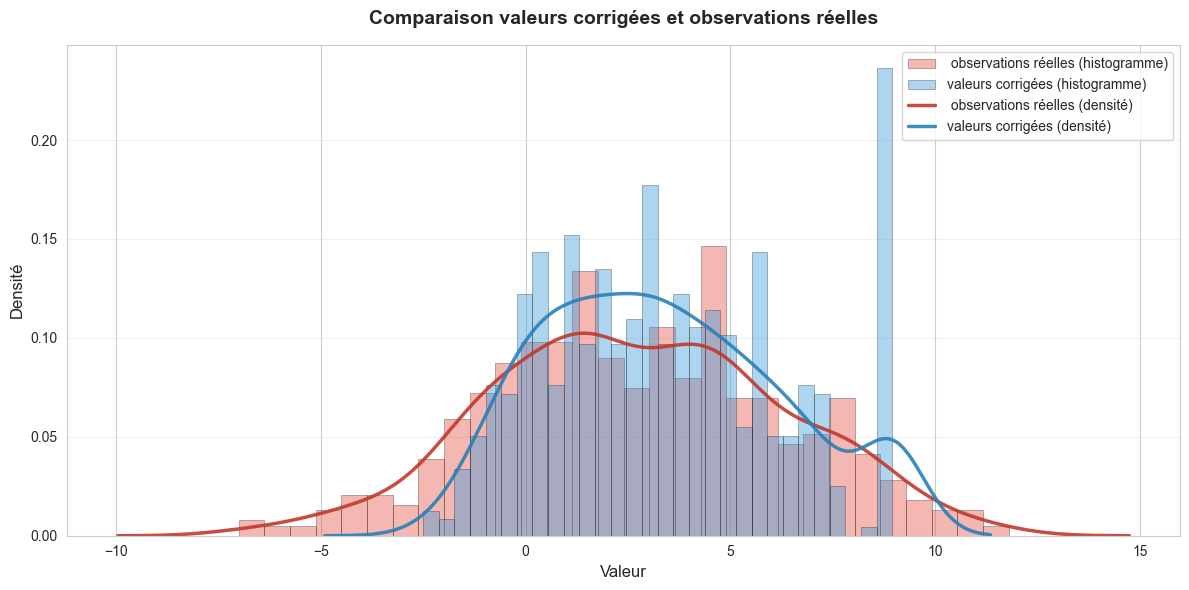

           Distribution  Espérance   Variance
0  Observations réelles   2.767601  12.631704
1     Valeurs corrigées   3.380726   8.362937
   Différence des espérances  Rapport des variances  KS statistique  \
0                   0.613125               0.662059        0.120968   

   KS p-value  
0    0.000226  


In [4]:
#Sélection mois et variable
CMIP6_hist = csv_to_pd_univ(r"data/CMIP6_historical.csv", month, "tas", years = (1975,1994))
CMIP6_futur = csv_to_pd_univ(r"data/CMIP6_historical.csv", month, "tas", years= (1995,2014))
obs_hist = csv_to_pd_univ(r"data/obs.csv", month, "tas", years = (1975,1994))
obs_futur = csv_to_pd_univ(r"data/obs.csv", month, "tas", years = (1995,2014))

#Correction des valeurs futures du modèle par CDF-t
_ ,modele_futur_corrige  = cdf_t_univ(CMIP6_hist,obs_hist,CMIP6_futur) 

#Comparaison graphique et statistique
plot_distributions((obs_futur, modele_futur_corrige),
                    "Comparaison valeurs corrigées et observations réelles",
                    ("observations réelles","valeurs corrigées"),)
stat, summary = comparer_distributions(obs_futur,"Observations réelles",modele_futur_corrige,"Valeurs corrigées")
print(stat)
print(summary)

In [5]:
#Comparaison modèle non corrigé et observations réelles sur 1995-2014
stat, summary = comparer_distributions(obs_futur,"Observations réelles",CMIP6_futur,"Modèle non corrigé")
print(stat)
print(summary)

           Distribution  Espérance   Variance
0  Observations réelles   2.767601  12.631704
1    Modèle non corrigé   0.910318  11.428635
   Différence des espérances  Rapport des variances  KS statistique  \
0                  -1.857283               0.904758        0.214516   

     KS p-value  
0  6.663891e-13  


### Validation croisée avec CMIP5 et Eurocordex

In [ ]:
#Sélection mois et variable
CMIP5_hist = csv_to_pd_univ(r"data/CMIP5_historical.csv", month, "tas", years = (1996,2005))
CMIP5_futur = csv_to_pd_univ(r"data/CMIP5_rcp85.csv", month, "tas", years= (2081,2100))
obs_hist = csv_to_pd_univ(r"data/eurocordex_historical.csv", month, "tas", years = (1996,2005))
obs_futur = csv_to_pd_univ(r"data/eurocordex_rcp85.csv", month, "tas", years = (2081,2100))

#Correction des valeurs futures du modèle par CDF-t
_ ,modele_futur_corrige  = cdf_t_univ(CMIP5_hist,obs_hist,CMIP5_futur) 

#Représentation graphique
plot_distributions((obs_futur, modele_futur_corrige),
                    "Comparaison valeurs corrigées et observations réelles",
                    ("observations réelles","valeurs corrigées"),)
stat, summary = comparer_distributions(obs_futur,"Observations réelles",modele_futur_corrige,"Valeurs corrigées")
print(stat)
print(summary)

In [ ]:
#Comparaison modèle non corrigé et observations réelles sur 2081-2100
stat, summary = comparer_distributions(obs_futur,"Observations réelles",CMIP5_futur,"Modèle non corrigé")
print(stat)
print(summary)

## Correction multivariée

### Cas gaussien

Rho de Spearman (Y1_gaussian) : -0.6922
Rho de Spearman (Y1_dOTC) : -0.6521
Différence : -0.0400


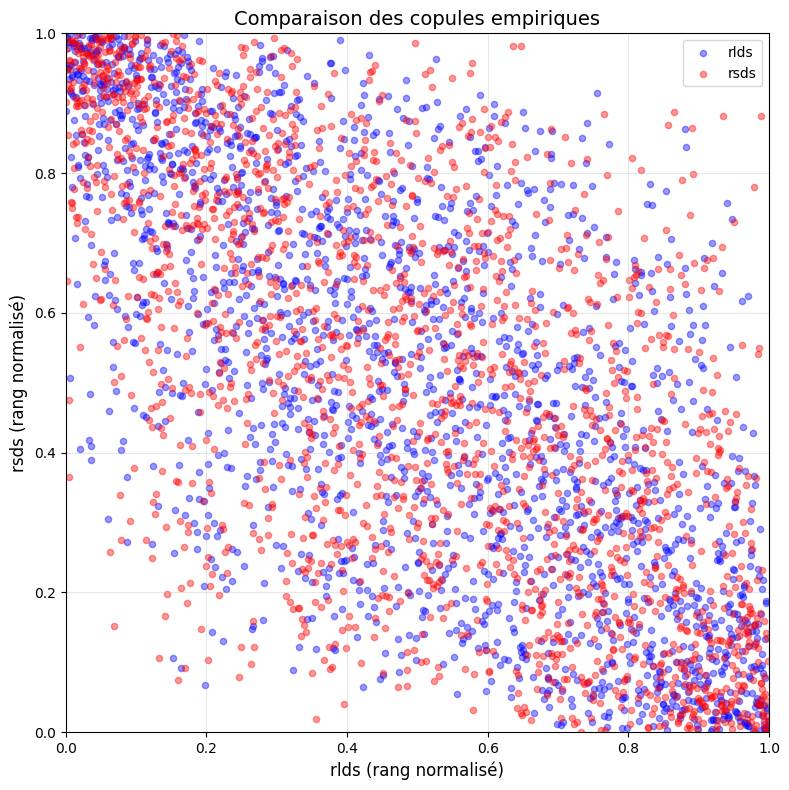

In [ ]:
#Charger les données multivariées
colonnes_communes = ["tas", "rlds", "rsds", "uas", "vas"]
colonnes_choisies = ["tas","rlds","rsds","uas","vas"]

CMIP6_hist  = extract_month_data("data/CMIP6_historical.csv", month, colonnes_choisies, (1975, 1994))
CMIP6_futur = extract_month_data("data/CMIP6_ssp585.csv",     month, colonnes_choisies, (2080, 2100))
obs_hist    = extract_month_data("data/obs.csv",               month, colonnes_choisies, (1975, 1994))

#Estimer les paramètres des lois normales multivariées (MLE)

mu_CMIP6_hist  = CMIP6_hist.mean(axis=0).values
mu_CMIP6_futur = CMIP6_futur.mean(axis=0).values
mu_obs_hist    = obs_hist.mean(axis=0).values

Sigma_CMIP6_hist  = np.cov(CMIP6_hist.values.T)
Sigma_CMIP6_futur = np.cov(CMIP6_futur.values.T)
Sigma_obs_hist    = np.cov(obs_hist.values.T)

#Simuler 2000 réalisations depuis chaque loi normale multivariée

n_simulations = 2000

sim_CMIP6_hist  = np.random.multivariate_normal(mu_CMIP6_hist,  Sigma_CMIP6_hist,  n_simulations)
sim_CMIP6_futur = np.random.multivariate_normal(mu_CMIP6_futur, Sigma_CMIP6_futur, n_simulations)
sim_obs_hist    = np.random.multivariate_normal(mu_obs_hist,    Sigma_obs_hist,    n_simulations)

CMIP6_hist_sim  = pd.DataFrame(sim_CMIP6_hist,  columns=colonnes_choisies)
CMIP6_futur_sim = pd.DataFrame(sim_CMIP6_futur, columns=colonnes_choisies)
obs_hist_sim    = pd.DataFrame(sim_obs_hist,     columns=colonnes_choisies)

#Construire Y1 de deux manières à partir des simulations

# --- Méthode 1 : gaussian_ot (Bures-Wasserstein, forme close) ---
# Apprend le transport linéaire X0->X1 (évolution du modèle)
# et l'applique à Y0 (observations) pour produire Y1
# Ordre des paramètres : (modele_hist, obs_hist, modele_futur)
Y1_gaussian = gaussian_ot(CMIP6_hist_sim, obs_hist_sim, CMIP6_futur_sim)

# --- Méthode 2 : dOTC_df (transport optimal dynamique, non-paramétrique) ---
# Même logique conceptuelle mais sans hypothèse gaussienne
# Ordre des paramètres : (X0, X1, Y0)
_, Y1_dOTC = dOTC_df(CMIP6_hist_sim, CMIP6_futur_sim, obs_hist_sim)

#Comparaison Y1_gaussian et Y1_dOTC : corrélation de Spearman et copules empiriques

variables = ['rlds', 'rsds']

rho1, rho2, diff = compare_spearman(Y1_gaussian, Y1_dOTC, variables)
print(f"Rho de Spearman (Y1_gaussian) : {rho1:.4f}")
print(f"Rho de Spearman (Y1_dOTC) : {rho2:.4f}")
print(f"Différence : {diff:.4f}")

compare_joint_distributions(Y1_gaussian, Y1_dOTC, variables)

### Simulations

In [ ]:
colonnes_communes = ["tas", "rlds", "rsds", "uas", "vas"]

for dim in range(1, len(colonnes_communes) + 1):
    colonnes_choisies = colonnes_communes[:dim]
    print(f"\n{'='*60}")
    print(f"Dimension {dim} : {colonnes_choisies}")
    print('='*60)

    CMIP6_hist  = extract_month_data("data/CMIP6_historical.csv", month, colonnes_choisies, (1975, 1994))
    CMIP6_futur = extract_month_data("data/CMIP6_historical.csv",     month, colonnes_choisies, (1995, 2014))
    obs_hist    = extract_month_data("data/obs.csv", month, colonnes_choisies, (1975, 1994))
    obs_futur   = extract_month_data("data/obs.csv", month, colonnes_choisies, (1995, 2014))

    mu_CMIP6_hist  = CMIP6_hist.mean(axis=0).values
    mu_CMIP6_futur = CMIP6_futur.mean(axis=0).values
    mu_obs_hist    = obs_hist.mean(axis=0).values
    mu_obs_futur   = obs_futur.mean(axis=0).values

    Sigma_CMIP6_hist  = np.cov(CMIP6_hist.values.T)
    Sigma_CMIP6_futur = np.cov(CMIP6_futur.values.T)
    Sigma_obs_hist    = np.cov(obs_hist.values.T)
    Sigma_obs_futur   = np.cov(obs_futur.values.T)

    # np.cov retourne un scalaire pour dim=1, il faut le convertir en matrice 1x1
    if dim == 1:
        Sigma_CMIP6_hist  = np.atleast_2d(Sigma_CMIP6_hist)
        Sigma_CMIP6_futur = np.atleast_2d(Sigma_CMIP6_futur)
        Sigma_obs_hist    = np.atleast_2d(Sigma_obs_hist)
        Sigma_obs_futur   = np.atleast_2d(Sigma_obs_futur)

    n_simulations = 2000
    sim_CMIP6_hist  = np.random.multivariate_normal(mu_CMIP6_hist,  Sigma_CMIP6_hist,  n_simulations)
    sim_CMIP6_futur = np.random.multivariate_normal(mu_CMIP6_futur, Sigma_CMIP6_futur, n_simulations)
    sim_obs_hist    = np.random.multivariate_normal(mu_obs_hist,    Sigma_obs_hist,    n_simulations)
    sim_obs_futur   = np.random.multivariate_normal(mu_obs_futur,   Sigma_obs_futur,   n_simulations)

    CMIP6_hist_sim  = pd.DataFrame(sim_CMIP6_hist,  columns=colonnes_choisies)
    CMIP6_futur_sim = pd.DataFrame(sim_CMIP6_futur, columns=colonnes_choisies)
    obs_hist_sim    = pd.DataFrame(sim_obs_hist,     columns=colonnes_choisies)
    obs_futur_sim   = pd.DataFrame(sim_obs_futur,    columns=colonnes_choisies)  # corrigé : DataFrame

    Y1_gaussian = gaussian_ot(CMIP6_hist_sim, obs_hist_sim, CMIP6_futur_sim)
    _, Y1_dOTC  = dOTC_df(CMIP6_hist_sim, CMIP6_futur_sim, obs_hist_sim)
    Y1_cdft     = cdf_t_multiv(CMIP6_hist_sim, obs_hist_sim, CMIP6_futur_sim)

    candidates = (
        (CMIP6_futur,   "Modèle non corrigé"),
        (Y1_cdft,       "CDF-t"),
        (Y1_dOTC,       "dOTC"),
        (Y1_gaussian,   "Transport linéaire"),
    )

    print(compare_spearman_frobenius(obs_futur, candidates))
    print()
    print(compare_distributions(obs_futur, candidates))


Dimension 1 : ['tas']
    Modèle/Correction  Norme de Frobenius
0  Modèle non corrigé                 0.0
1               CDF-t                 0.0
2                dOTC                 0.0
3  Transport linéaire                 0.0

    Modèle/Correction Variable  Diff. espérances  Rapport des variances  \
0  Modèle non corrigé      tas          1.857283               1.105268   
1               CDF-t      tas         -0.857611               1.586490   
2                dOTC      tas         -0.676263               1.433769   
3  Transport linéaire      tas         -1.046689               1.567826   

     KS p-value  
0  6.663891e-13  
1  3.971147e-14  
2  1.425165e-08  
3  5.343744e-16  

Dimension 2 : ['tas', 'rlds']
    Modèle/Correction  Norme de Frobenius
0  Modèle non corrigé            0.165416
1               CDF-t            0.134546
2                dOTC            0.252368
3  Transport linéaire            0.287023

    Modèle/Correction Variable  Diff. espérances  Rapport 

### Validation croisée sur données réelles

In [ ]:
colonnes_communes = ["tas", "rlds", "rsds", "uas", "vas"]

for dim in range(1, len(colonnes_communes) + 1):
    colonnes_choisies = colonnes_communes[:dim]
    print(f"\n{'='*60}")
    print(f"Dimension {dim} : {colonnes_choisies}")
    print('='*60)

    CMIP6_hist  = extract_month_data("data/CMIP6_historical.csv", month, colonnes_choisies, (1975, 1994))
    CMIP6_futur = extract_month_data("data/CMIP6_historical.csv",     month, colonnes_choisies, (1995, 2014))
    obs_hist    = extract_month_data("data/obs.csv", month, colonnes_choisies, (1975, 1994))
    obs_futur   = extract_month_data("data/obs.csv", month, colonnes_choisies, (1995, 2014))

    Y1_gaussian = gaussian_ot(CMIP6_hist, obs_hist, CMIP6_futur)
    _, Y1_dOTC  = dOTC_df(CMIP6_hist, CMIP6_futur, obs_hist)
    Y1_cdft     = cdf_t_multiv(CMIP6_hist, obs_hist, CMIP6_futur)

    candidates = (
        (CMIP6_futur,   "Modèle non corrigé"),
        (Y1_cdft,       "CDF-t"),
        (Y1_dOTC,       "dOTC"),
        (Y1_gaussian,   "Transport linéaire"),
    )

    print(compare_spearman_frobenius(obs_futur, candidates))
    print()
    print(compare_distributions(obs_futur, candidates))


Dimension 1 : ['tas']
    Modèle/Correction  Norme de Frobenius
0  Modèle non corrigé                 0.0
1               CDF-t                 0.0
2                dOTC                 0.0
3  Transport linéaire                 0.0

    Modèle/Correction Variable  Diff. espérances  Rapport des variances  \
0  Modèle non corrigé      tas          1.857283               1.105268   
1               CDF-t      tas         -0.613125               1.510439   
2                dOTC      tas         -0.601673               1.208719   
3  Transport linéaire      tas         -0.953403               1.673876   

     KS p-value  
0  6.663891e-13  
1  2.261473e-04  
2  2.685915e-03  
3  5.040449e-08  

Dimension 2 : ['tas', 'rlds']
    Modèle/Correction  Norme de Frobenius
0  Modèle non corrigé            0.165416
1               CDF-t            0.166294
2                dOTC            0.355124
3  Transport linéaire            0.299333

    Modèle/Correction Variable  Diff. espérances  Rapport 

### Validation croisée sur modèle régional

In [10]:
colonnes_communes = ["tas", "sfcWind", "rlds", "rsds", "huss", "uas", "vas"]

for dim in range(1, len(colonnes_communes) + 1):
    colonnes_choisies = colonnes_communes[:dim]
    print(f"\n{'='*60}")
    print(f"Dimension {dim} : {colonnes_choisies}")
    print('='*60)

    CMIP5_hist  = extract_month_data("data/CMIP5_historical.csv", month, colonnes_choisies, (1996, 2005))
    CMIP5_futur = extract_month_data("data/CMIP5_rcp85.csv",     month, colonnes_choisies, (2081, 2100))
    obs_hist    = extract_month_data("data/eurocordex_historical.csv", month, colonnes_choisies, (1996, 2005))
    obs_futur   = extract_month_data("data/eurocordex_rcp85.csv", month, colonnes_choisies, (2081, 2100))

    Y1_gaussian = gaussian_ot(CMIP5_hist, obs_hist, CMIP5_futur)
    _, Y1_dOTC  = dOTC_df(CMIP5_hist, CMIP5_futur, obs_hist)
    Y1_cdft     = cdf_t_multiv(CMIP5_hist, obs_hist, CMIP5_futur)

    candidates = (
        (CMIP5_futur,   "Modèle non corrigé"),
        (Y1_cdft,       "CDF-t"),
        (Y1_dOTC,       "dOTC"),
        (Y1_gaussian,   "Transport linéaire"),
    )

    print(compare_spearman_frobenius(obs_futur, candidates))
    print()
    print(compare_distributions(obs_futur, candidates))


Dimension 1 : ['tas']
    Modèle/Correction  Norme de Frobenius
0  Modèle non corrigé                 0.0
1               CDF-t                 0.0
2                dOTC                 0.0
3  Transport linéaire                 0.0

    Modèle/Correction Variable  Diff. espérances  Rapport des variances  \
0  Modèle non corrigé      tas         -0.433944               1.264354   
1               CDF-t      tas          0.146671               1.224978   
2                dOTC      tas          0.033116               1.155927   
3  Transport linéaire      tas          0.063240               1.190956   

   KS p-value  
0    0.012680  
1    0.151430  
2    0.506693  
3    0.448037  

Dimension 2 : ['tas', 'sfcWind']
    Modèle/Correction  Norme de Frobenius
0  Modèle non corrigé            0.253150
1               CDF-t            0.253452
2                dOTC            0.310181
3  Transport linéaire            0.249407

    Modèle/Correction Variable  Diff. espérances  Rapport des var